In [233]:
import pickle as pkl
model=pkl.dump(model,open("model.pkl","wb"))
labelEncoder=pkl.dump(labelEncoder,open("labelEncoder.pkl",'wb'))
pkl.dump(colNum,open("colNum.pkl","wb"))
pkl.dump(colText,open("colText.pkl","wb"))

In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
import xgboost
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, precision_score,f1_score,recall_score,classification_report,fbeta_score

In [189]:
# dataset
loan=pd.read_csv("loan_approval_training_dataset.csv")

In [190]:
loan

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loanstatus
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [191]:
# handle spaces and other syymbols to columns
loan.columns = loan.columns.str.strip().str.replace(" ", "").str.replace("_", "")
loan.columns = loan.columns.str[0].str.lower() + loan.columns.str[1:]

In [192]:
loan.columns

Index(['loanid', 'noofdependents', 'education', 'selfemployed', 'incomeannum',
       'loanamount', 'loanterm', 'cibilscore', 'residentialassetsvalue',
       'commercialassetsvalue', 'luxuryassetsvalue', 'bankassetvalue',
       'loanstatus'],
      dtype='object')

In [193]:
# Handling spaces in records,
for cols in loan.columns:
    if loan[cols].dtypes=="object":
        loan[cols]=loan[cols].str.replace(" ","",regex=False).str.strip()

In [194]:

# # encode education and selfemployed columns
loan['education'] = loan['education'].map({"Graduate": 1, "NotGraduate": 0})


In [195]:
loan['selfemployed'] = loan['selfemployed'].map({"Yes": 1, "No": 0})

In [196]:
loan["selfemployed"].isnull().sum()

np.int64(0)

In [197]:
loan['education'].isnull().sum()

np.int64(0)

In [198]:
loan['education']

0       1
1       0
2       1
3       1
4       0
       ..
4264    1
4265    0
4266    0
4267    0
4268    1
Name: education, Length: 4269, dtype: int64

In [199]:
loan['education'].value_counts()

education
1    2144
0    2125
Name: count, dtype: int64

In [200]:
loan['education'].isnull().sum()

np.int64(0)

In [202]:
# Numerical and non numerical columns
colNum=['noofdependents',
 'incomeannum',
 'loanamount',
 'residentialassetsvalue',
 'commercialassetsvalue',
 'luxuryassetsvalue',
 'bankassetvalue']

colText=['education', 'selfemployed', 'loanstatus']

In [87]:
# # Handling spaces for records
# for records in loan.columns:
#     if loan[records].dtype not in ['int64','float64']:
#         # loan[records]=loan[records].str.strip()

In [203]:
# exclude loadid,cibilscore and loanterm cols
loan=loan.drop(columns=['loanid','cibilscore','loanterm'])

In [48]:
# check null values
# loan.isnull().sum()

In [204]:
loan['education'].dtype

dtype('int64')

In [205]:
print(loan['education'].unique())
print(loan['education'].isna().sum())
print(loan.shape)

[1 0]
0
(4269, 10)


In [135]:
loan

,noofdependents,education,selfemployed,incomeannum,loanamount,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue,loanstatus
0,2,1,0,9600000,29900000,2400000,17600000,22700000,8000000,Approved
1,0,0,1,4100000,12200000,2700000,2200000,8800000,3300000,Rejected
2,3,1,0,9100000,29700000,7100000,4500000,33300000,12800000,Rejected
3,3,1,0,8200000,30700000,18200000,3300000,23300000,7900000,Rejected
4,5,0,1,9800000,24200000,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1,1000000,2300000,2800000,500000,3300000,800000,Rejected
4265,0,0,1,3300000,11300000,4200000,2900000,11000000,1900000,Approved
4266,2,0,0,6500000,23900000,1200000,12400000,18100000,7300000,Rejected
4267,1,0,0,4100000,12800000,8200000,700000,14100000,5800000,Approved


In [206]:
# split data
x=loan.drop(columns=["loanstatus"])
y=loan["loanstatus"]
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=0.20,random_state=49)

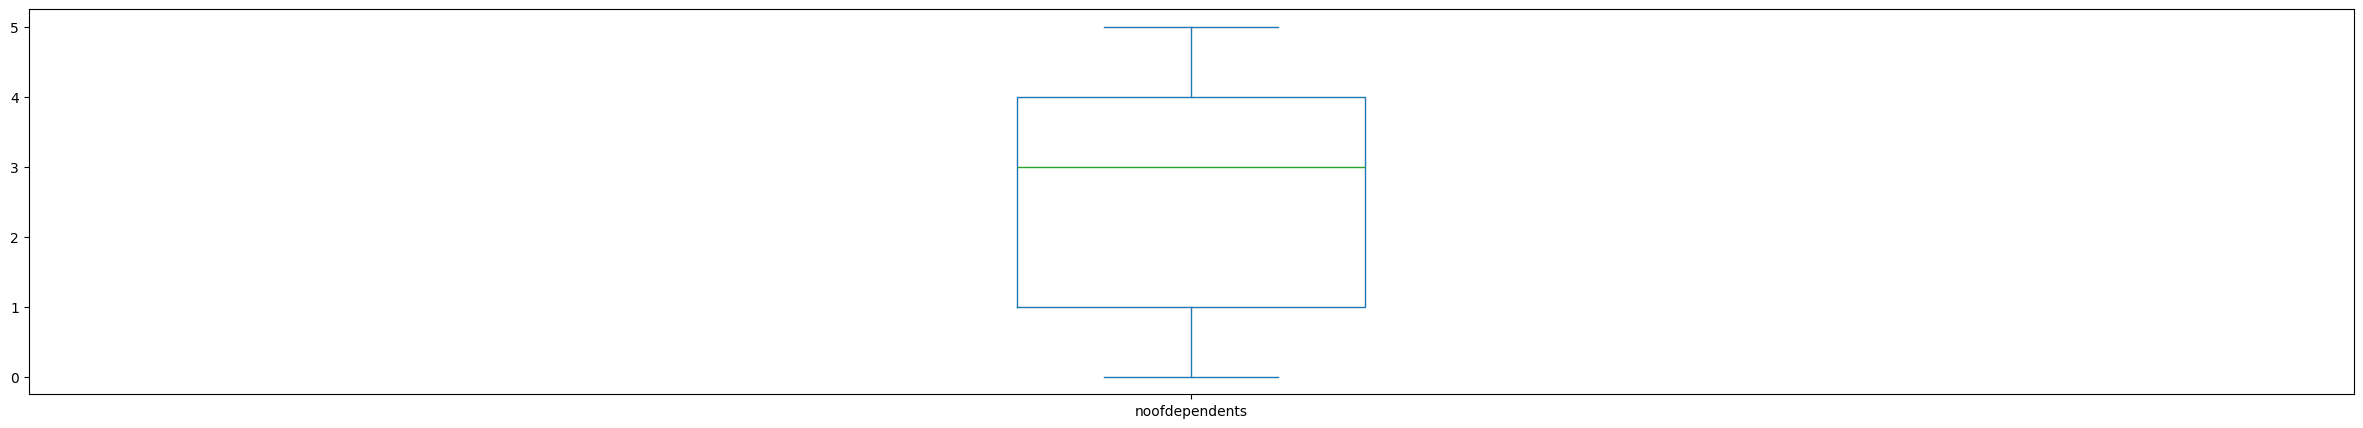

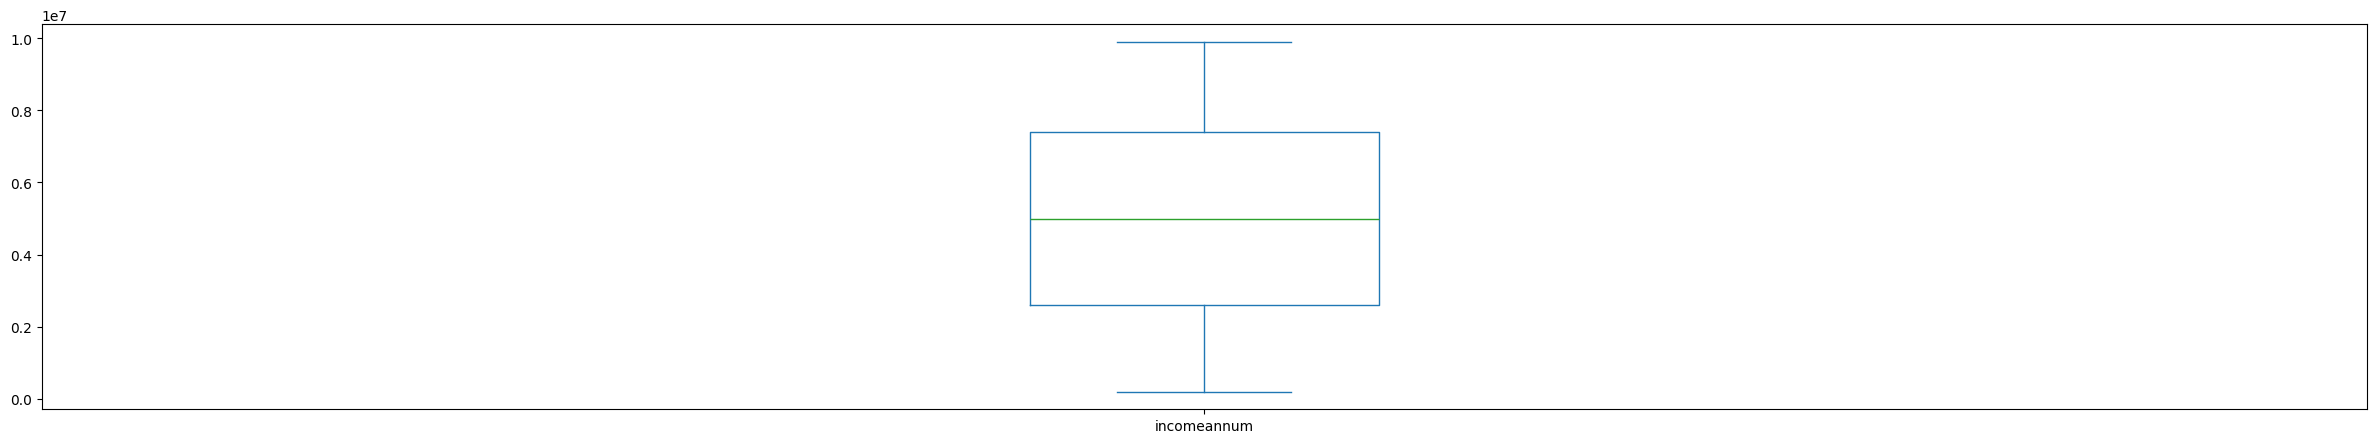

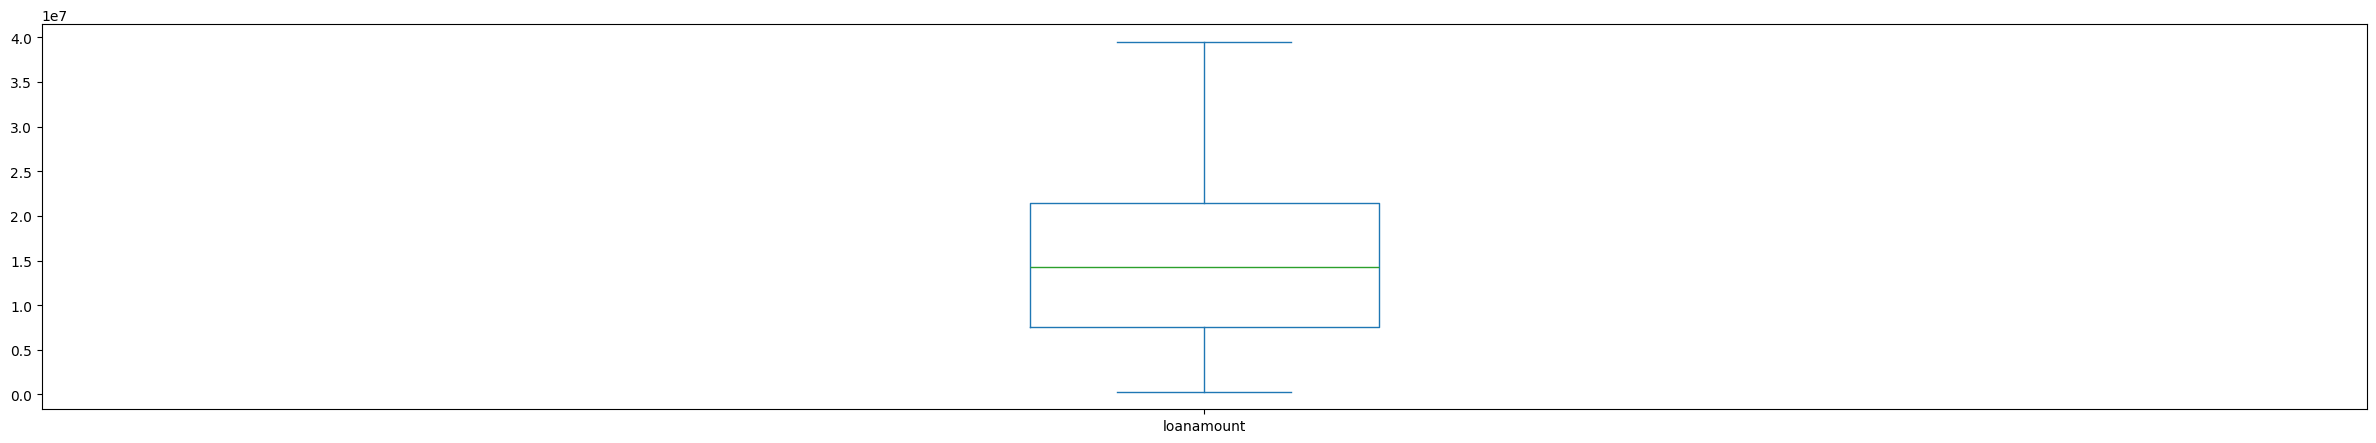

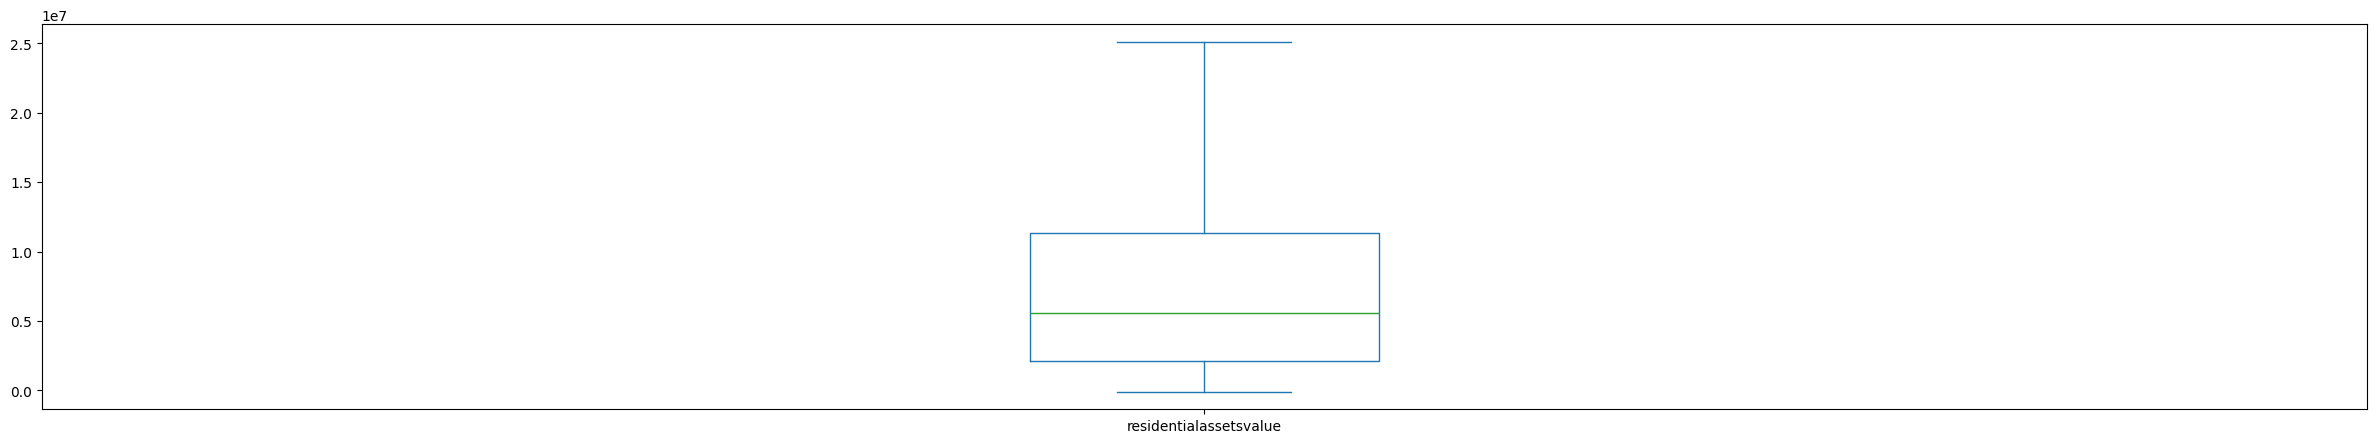

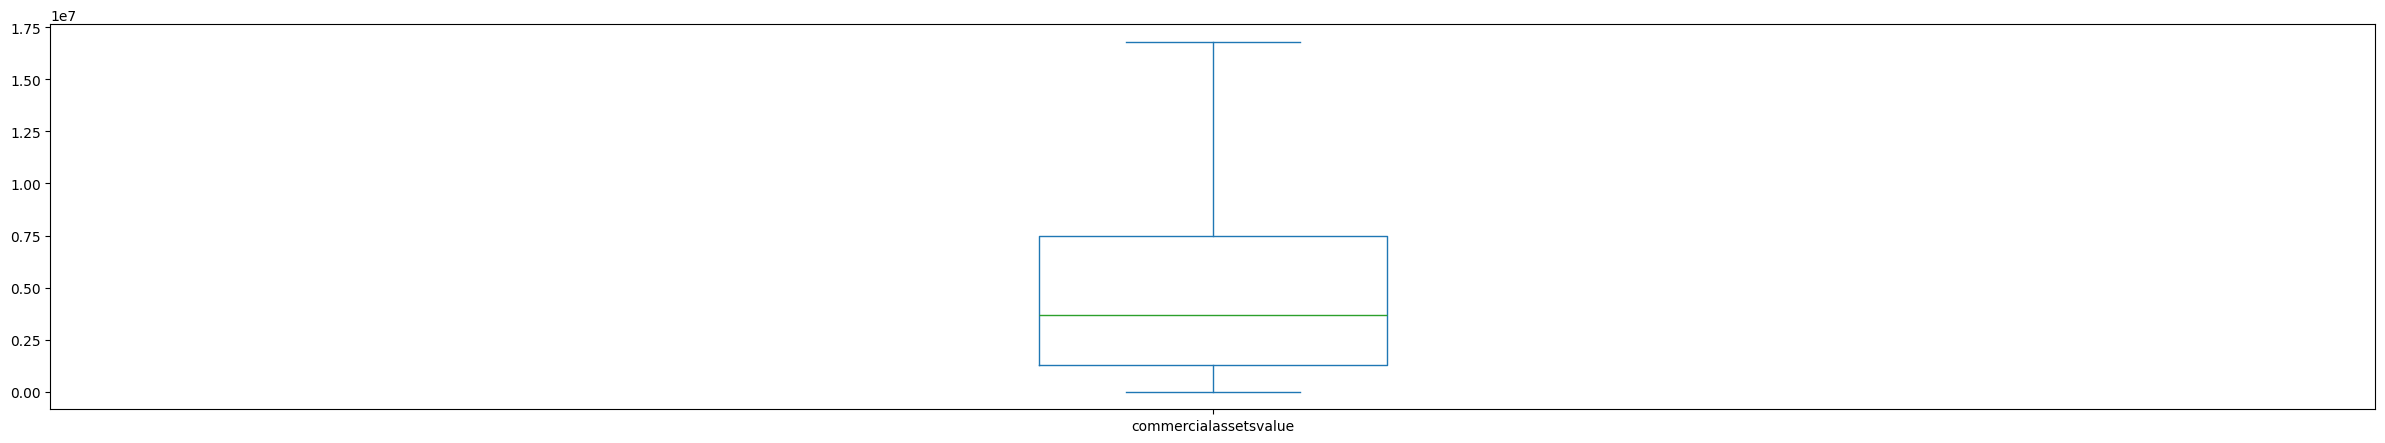

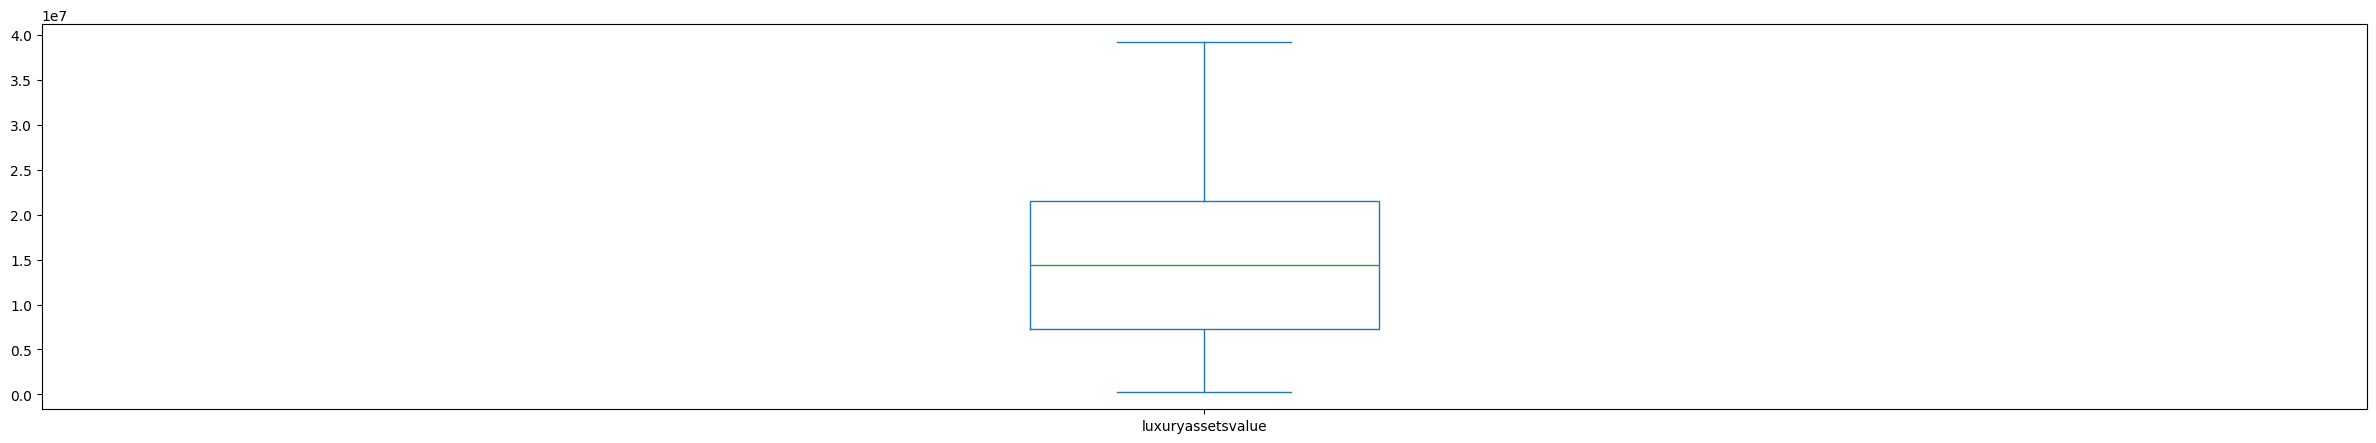

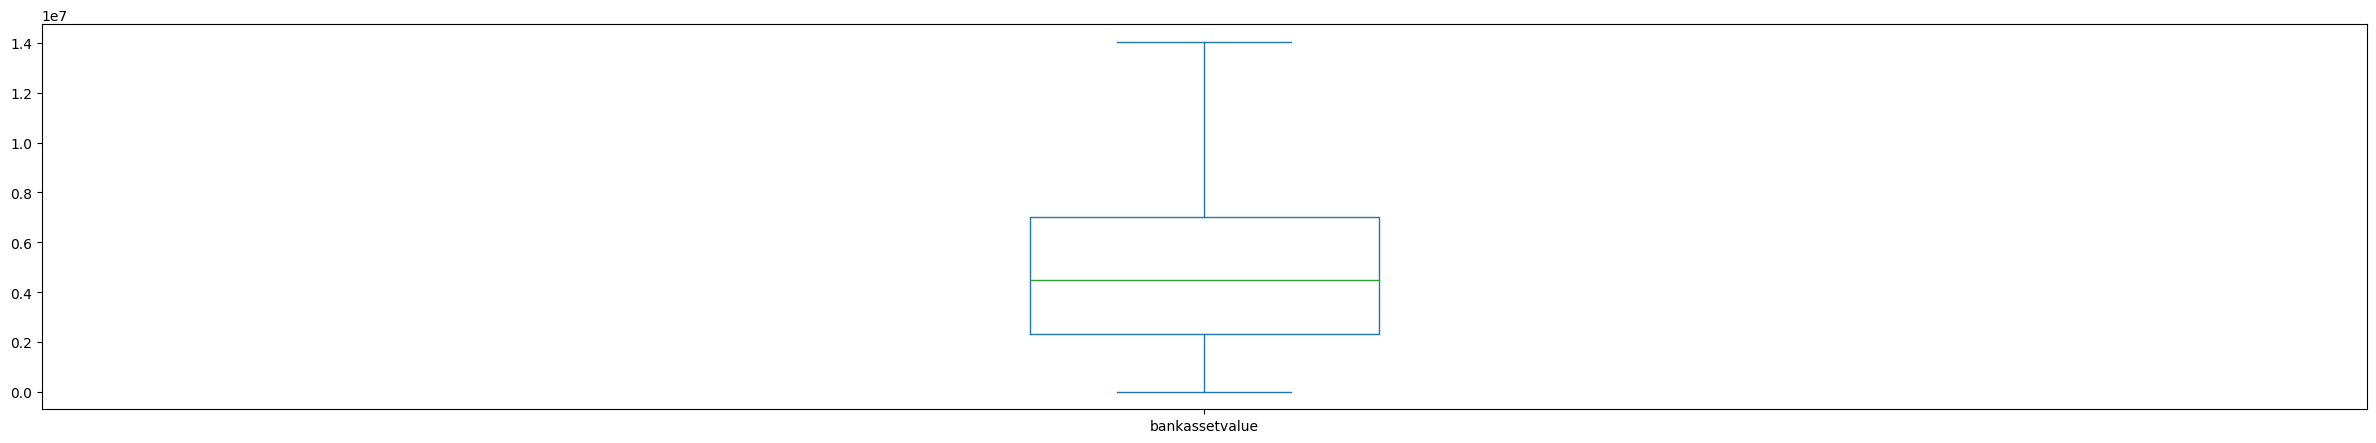

In [210]:
# check for outliers
for out in colNum:
        plt.figure(figsize=(30,5))
        xTrain[out].plot(kind="box")
        # plt.show()

In [208]:
# /handling  outliers
bounds={}
for handleOutliers in colNum:
    if handleOutliers not in colText:
        Q1=xTrain[handleOutliers].quantile(0.25)
        Q3=xTrain[handleOutliers].quantile(0.75)
        IQR=Q3-Q1
    
        Upper=Q3+1.5*IQR
        Lower=Q1-1.5*IQR
        
        # countOut=loan.loc[(loan[handleOutliers]<Lower) | (loan[handleOutliers]>Upper)].shape[0]
        # if countOut!=0:
        bounds[handleOutliers]={"lower":Lower,"upper":Upper}
        xTrain[handleOutliers]=xTrain[handleOutliers].clip(lower=Lower,upper=Upper)
        xTest[handleOutliers]=xTest[handleOutliers].clip(lower=Lower,upper=Upper)
pkl.dump(bounds,open("bounds.pkl","wb"))

In [211]:
loan

,noofdependents,education,selfemployed,incomeannum,loanamount,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue,loanstatus
0,2,1,0,9600000,29900000,2400000,17600000,22700000,8000000,Approved
1,0,0,1,4100000,12200000,2700000,2200000,8800000,3300000,Rejected
2,3,1,0,9100000,29700000,7100000,4500000,33300000,12800000,Rejected
3,3,1,0,8200000,30700000,18200000,3300000,23300000,7900000,Rejected
4,5,0,1,9800000,24200000,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1,1000000,2300000,2800000,500000,3300000,800000,Rejected
4265,0,0,1,3300000,11300000,4200000,2900000,11000000,1900000,Approved
4266,2,0,0,6500000,23900000,1200000,12400000,18100000,7300000,Rejected
4267,1,0,0,4100000,12800000,8200000,700000,14100000,5800000,Approved


In [212]:
# Encoder for target var
labelEncoder=LabelEncoder()

In [213]:
# encode yTrain
yTrain=labelEncoder.fit_transform(yTrain)

In [214]:
# encode y test
yTest=labelEncoder.transform(yTest)

In [215]:
xTrain

,noofdependents,education,selfemployed,incomeannum,loanamount,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue
3938,5,0,1,4700000,11800000,3600000,700000,9400000,5500000
4221,3,1,1,1300000,4300000,600000,900000,5200000,1200000
1534,1,0,0,2600000,7900000,2000000,2400000,7600000,3300000
1207,1,0,1,300000,600000,600000,300000,1100000,200000
1006,4,1,1,2500000,8400000,6300000,1300000,8400000,1600000
...,...,...,...,...,...,...,...,...,...
1946,2,1,0,8400000,32100000,16300000,4600000,19500000,8000000
224,3,0,1,700000,1700000,1200000,800000,2400000,500000
3724,0,1,0,5200000,12200000,5000000,2000000,11400000,5100000
3254,3,1,0,7400000,28800000,20000000,7900000,23600000,7200000


In [216]:
yTrain

array([0, 1, 1, ..., 0, 1, 1], shape=(3415,))

In [217]:
xTrain

,noofdependents,education,selfemployed,incomeannum,loanamount,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue
3938,5,0,1,4700000,11800000,3600000,700000,9400000,5500000
4221,3,1,1,1300000,4300000,600000,900000,5200000,1200000
1534,1,0,0,2600000,7900000,2000000,2400000,7600000,3300000
1207,1,0,1,300000,600000,600000,300000,1100000,200000
1006,4,1,1,2500000,8400000,6300000,1300000,8400000,1600000
...,...,...,...,...,...,...,...,...,...
1946,2,1,0,8400000,32100000,16300000,4600000,19500000,8000000
224,3,0,1,700000,1700000,1200000,800000,2400000,500000
3724,0,1,0,5200000,12200000,5000000,2000000,11400000,5100000
3254,3,1,0,7400000,28800000,20000000,7900000,23600000,7200000


In [218]:
yTrain

array([0, 1, 1, ..., 0, 1, 1], shape=(3415,))

In [219]:
xTrain=pd.DataFrame(xTrain)

In [220]:
yTrain=pd.DataFrame(yTrain)

In [221]:
concat=pd.concat([xTrain.reset_index(drop=True),yTrain.reset_index(drop=True)],axis=1)

In [222]:
concat.corr()

,noofdependents,education,selfemployed,incomeannum,loanamount,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue,0
noofdependents,1.000000,-0.003714,0.001464,0.003235,-0.009201,0.018485,0.005991,0.005954,0.009539,0.008929
education,-0.003714,1.000000,-0.009685,0.025216,0.021938,0.016161,-0.005151,0.024185,0.020012,0.010914
selfemployed,0.001464,-0.009685,1.000000,0.005018,0.006108,-0.001404,-0.017650,0.002685,0.007805,0.001744
incomeannum,0.003235,0.025216,0.005018,1.000000,0.928887,0.639905,0.642535,0.930903,0.852914,0.013128
loanamount,-0.009201,0.021938,0.006108,0.928887,1.000000,0.597050,0.603367,0.865885,0.792937,-0.014858
residentialassetsvalue,0.018485,0.016161,-0.001404,0.639905,0.597050,1.000000,0.430345,0.594954,0.530863,0.014733
commercialassetsvalue,0.005991,-0.005151,-0.017650,0.642535,0.603367,0.430345,1.000000,0.598841,0.544863,-0.004658
luxuryassetsvalue,0.005954,0.024185,0.002685,0.930903,0.865885,0.594954,0.598841,1.000000,0.794035,0.015840
bankassetvalue,0.009539,0.020012,0.007805,0.852914,0.792937,0.530863,0.544863,0.794035,1.000000,0.013103
0,0.008929,0.010914,0.001744,0.013128,-0.014858,0.014733,-0.004658,0.015840,0.013103,1.000000


In [223]:
trainingFrame=pd.concat([xTrain.reset_index(drop=True),yTrain.reset_index(drop=True)],axis=1)

In [224]:
trainingFrame

,noofdependents,education,selfemployed,incomeannum,loanamount,residentialassetsvalue,commercialassetsvalue,luxuryassetsvalue,bankassetvalue,0
0,5,0,1,4700000,11800000,3600000,700000,9400000,5500000,0
1,3,1,1,1300000,4300000,600000,900000,5200000,1200000,1
2,1,0,0,2600000,7900000,2000000,2400000,7600000,3300000,1
3,1,0,1,300000,600000,600000,300000,1100000,200000,0
4,4,1,1,2500000,8400000,6300000,1300000,8400000,1600000,0
...,...,...,...,...,...,...,...,...,...,...
3410,2,1,0,8400000,32100000,16300000,4600000,19500000,8000000,1
3411,3,0,1,700000,1700000,1200000,800000,2400000,500000,0
3412,0,1,0,5200000,12200000,5000000,2000000,11400000,5100000,0
3413,3,1,0,7400000,28800000,20000000,7900000,23600000,7200000,1


In [225]:
# Realationship is non linear, xgboost is a go to Model
model=XGBClassifier(learning_rate=0.01, 
                    n_estimators=1000,
                    reg_alpha=1,
                    reg_lambda=0.1)
model.fit(xTrain,yTrain)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [226]:
# Prediction
prediction=model.predict(xTest)


In [227]:
# Compute classification report
modelReport=classification_report(yTest,prediction,target_names=labelEncoder.classes_,output_dict=True)

In [228]:
modelReport

{'Approved': {'precision': 0.6061026352288488,
  'recall': 0.8485436893203884,
  'f1-score': 0.7071197411003236,
  'support': 515.0},
 'Rejected': {'precision': 0.41353383458646614,
  'recall': 0.16224188790560473,
  'f1-score': 0.2330508474576271,
  'support': 339.0},
 'accuracy': 0.5761124121779859,
 'macro avg': {'precision': 0.5098182349076574,
  'recall': 0.5053927886129965,
  'f1-score': 0.4700852942789754,
  'support': 854.0},
 'weighted avg': {'precision': 0.5296613900089803,
  'recall': 0.5761124121779859,
  'f1-score': 0.5189354847245928,
  'support': 854.0}}

In [229]:
reportFrame=pd.DataFrame(modelReport).transpose()

In [230]:
reportFrame

,precision,recall,f1-score,support
Approved,0.606103,0.848544,0.707120,515.000000
Rejected,0.413534,0.162242,0.233051,339.000000
accuracy,0.576112,0.576112,0.576112,0.576112
macro avg,0.509818,0.505393,0.470085,854.000000
weighted avg,0.529661,0.576112,0.518935,854.000000


In [231]:
# computer probability
probability=model.predict_proba(xTest)

In [232]:
model.classes_

array([0, 1])